# 1. Import libraries and data

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os

sys.path.append(os.getcwd())
sys.path.append(f"{os.getcwd()}/..")


In [2]:
# from wifiplotting import OSMPlotContext, plot_wifi_heatmap, TL_CORNER, BR_CORNER
import wifiplotting as wp
from wifiplotting import TL_CORNER, BR_CORNER

In [3]:
wifi_df = pd.read_csv('../../data/df_clean.csv')

In [4]:
# filter for data in sequoia area

sequoia = lambda df: (BR_CORNER[0] <= df['latitude']) &  (df['latitude'] <= TL_CORNER[0]) & \
            (TL_CORNER[1] <= df['longitude']) & (df['longitude'] <= BR_CORNER[1])

wifi_df = wifi_df[sequoia]
# wifi_df = wifi_df[wifi_df['indoor'] == True]

wifi_df.to_csv('../data/sequoia.csv', index=False, na_rep="null")

In [5]:
wifi_df.head()

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1


In [6]:
agg_wifi_df = wifi_df.sort_values("index").groupby("mid").first().drop(
    ['index', 'rssi_sample', 'rssi_signal_measured', 'noise_sample', 'noise_signal_measured'], axis=1
)

In [7]:
agg_wifi_df.head()

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_n_valid,noise_set,noise_n_valid,timestamp,location_timestamp
mid,,,,,,,,,,,,,
003076bbb880,2026-05-02,14:40:08.090794,37.429963,-122.173400,True,ee:9e:38:db:0c:ab,1,-73.000000,3,-98.333333,3,2026-05-02 14:40:08.090794-07:00,2026-05-02 21:40:04+00:00
0034cd7495f0,2026-05-08,15:39:57.318153,37.429837,-122.170812,False,00:f6:63:e6:50:d1,2,-89.000000,3,-96.000000,3,2026-05-08 15:39:57.318153-07:00,2026-05-08 22:39:58+00:00
0048115ad55b,2026-05-02,14:25:30.525771,37.429920,-122.171696,True,a8:3a:79:ca:ef:92,1,-58.333333,3,-96.000000,3,2026-05-02 14:25:30.525771-07:00,2026-05-02 21:25:35+00:00
006dbec187a3,2026-05-11,17:40:46.221977,37.427628,-122.170234,False,70:61:7b:d7:4c:ee,1,-71.333333,3,-97.666667,3,2026-05-11 17:40:46.221977-07:00,2026-05-12 00:40:46+00:00
007522cdb4d5,2026-05-01,14:51:16.693670,37.429164,-122.172836,True,c8:78:67:36:40:52,1,-76.333333,3,-98.000000,3,2026-05-01 14:51:16.693670-07:00,2026-05-01 21:51:15+00:00


In [8]:
wifi_df['ap'].nunique(), agg_wifi_df['ap'].nunique()

(318, 318)

In [9]:
wifi_df.head()

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1


{'bounds': (-122.17471237999999, 37.42635, -122.16860462000001, 37.431282),
 'zoom': 17,
 'basemap_loaded': True,
 'buildings_loaded': True,
 'building_count': 36,
 'basemap_error': None,
 'building_error': None}

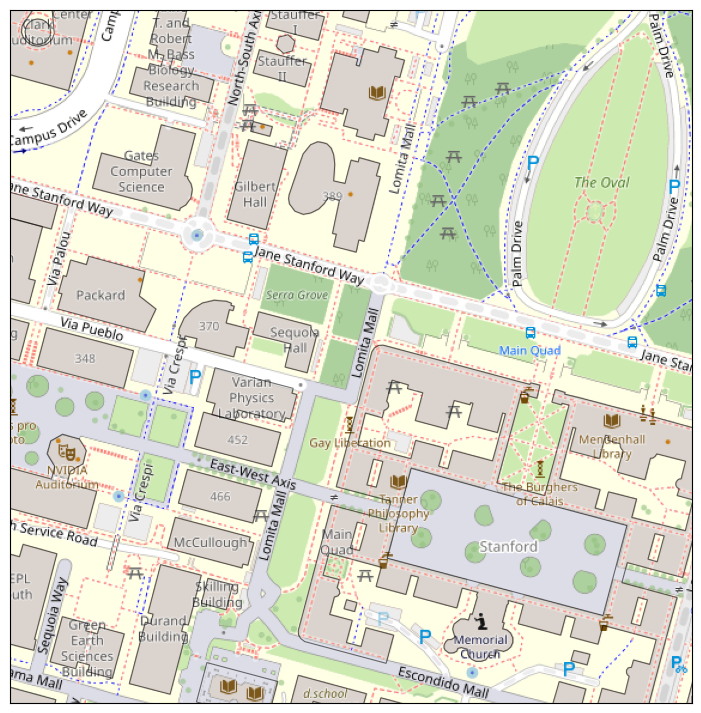

In [10]:
osm_context = wp.OSMPlotContext.from_bounds(
    init_lons=[BR_CORNER[1], TL_CORNER[1]], init_lats=[BR_CORNER[0], TL_CORNER[0]])
fig, ax, osm_metadata = osm_context.generate_base_axis()
osm_metadata

# verifying indoor vs outdoor detection

In [11]:
grid_lons = np.linspace(BR_CORNER[1], TL_CORNER[1], 100)
grid_lats = np.linspace(TL_CORNER[0], BR_CORNER[0], 100)
grid_x, grid_y = np.meshgrid(grid_lons, grid_lats)
world_x, world_y = osm_context.to_world(grid_x, grid_y)
in_building = osm_context.contains_building(grid_x, grid_y)

<Axes: >

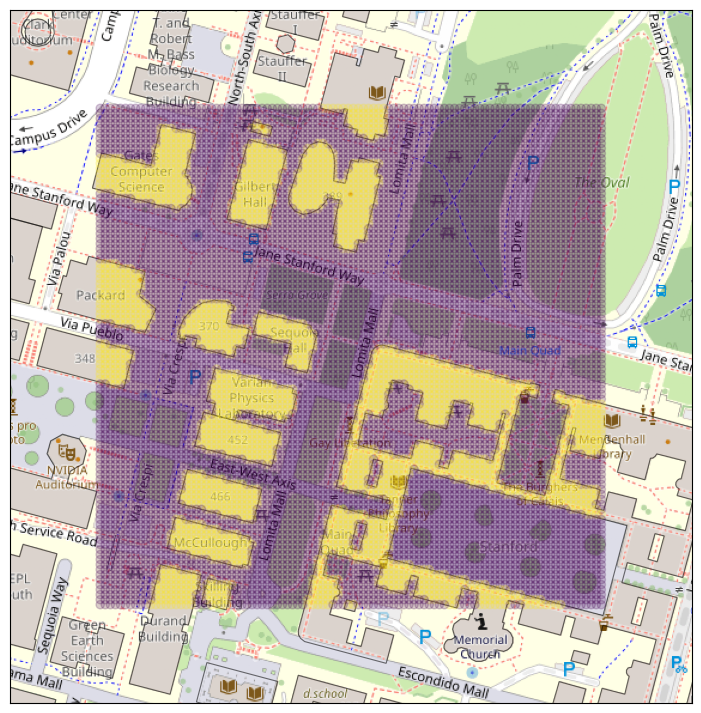

In [12]:
fig, ax, osm_metadata = osm_context.generate_base_axis()
ax.scatter(
    world_x,
    world_y,
    c=in_building,
    alpha = 0.2,
)
ax

# Some exploratory plots

In [13]:
import importlib

In [14]:
import wifiplotting as wp

In [15]:
importlib.reload(wp)

<module 'wifiplotting' from '/home/jamie/storage-1/github-repos/where-my-wifi-kevin/code/milestone2/../wifiplotting.py'>

RSSI heatmap uses 2171 unique coordinate bins from 8095 rows.


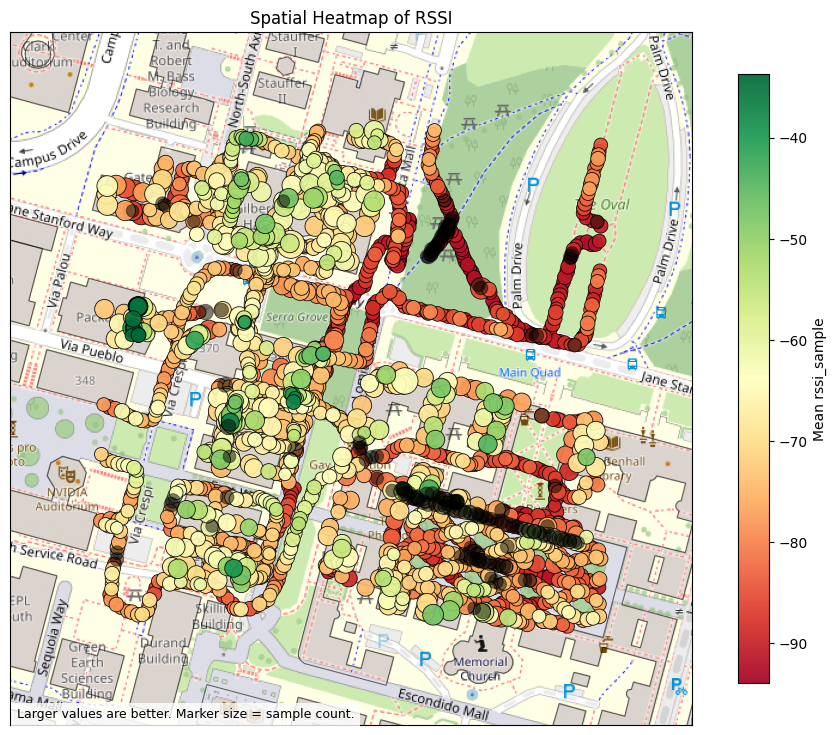

In [16]:
fig, ax, rssi_points, na_points = wp.plot_agg_wifi_heatmap(wifi_df, show_na=0.5, context=osm_context)
rows_used = int(rssi_points["sample_count"].sum() + na_points["sample_count"].sum())
print(f"RSSI heatmap uses {len(rssi_points) + len(na_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

Noise heatmap uses 1861 unique coordinate bins from 6701 rows.


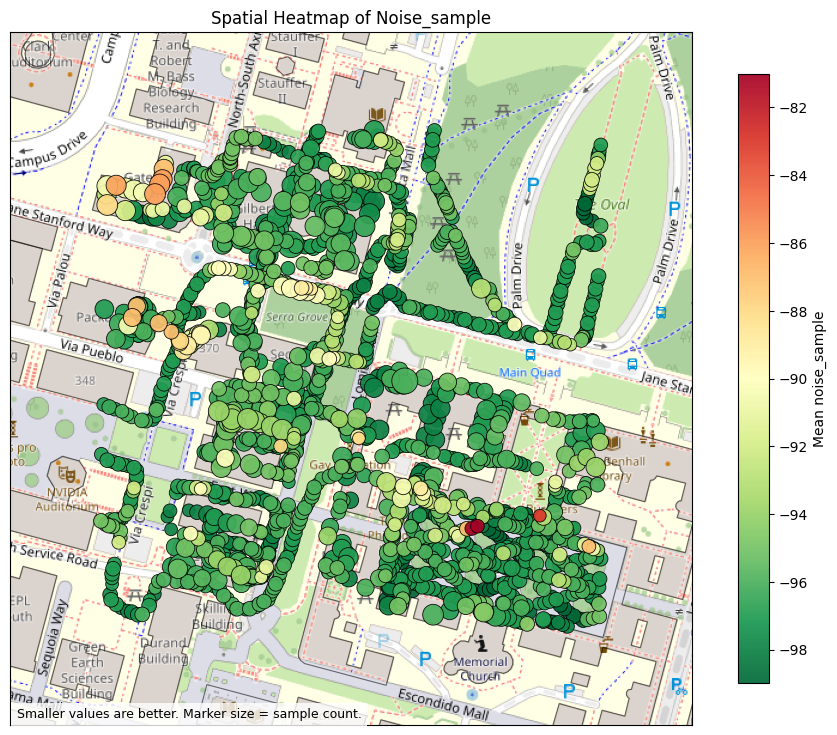

In [17]:
fig, ax, noise_points, na_points = wp.plot_agg_wifi_heatmap(wifi_df, value="noise_sample", invert_cmap=True, context=osm_context)
rows_used = int(noise_points["sample_count"].sum())
print(f"Noise heatmap uses {len(noise_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

In [18]:
snr = wifi_df['rssi_sample'] - wifi_df['noise_sample']

SNR heatmap uses 1861 unique coordinate bins from 6694 rows.


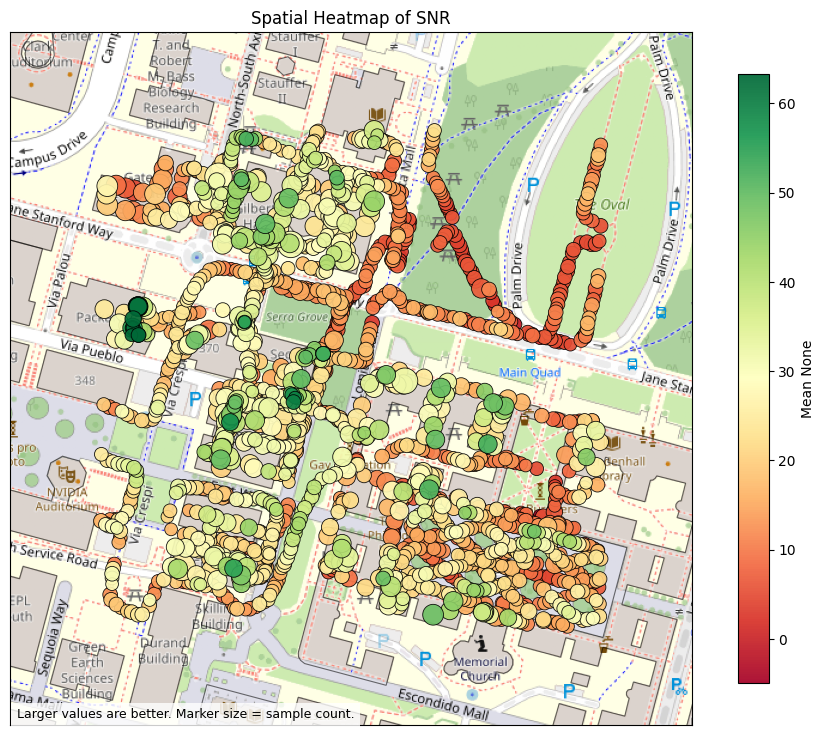

In [19]:
fig, ax, snr_points, na_points = wp.plot_agg_wifi_heatmap(wifi_df, new_data=snr, plotname='SNR', context=osm_context)
rows_used = int(snr_points["sample_count"].sum())
print(f"SNR heatmap uses {len(snr_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

# 3. Indoors vs. outdoors

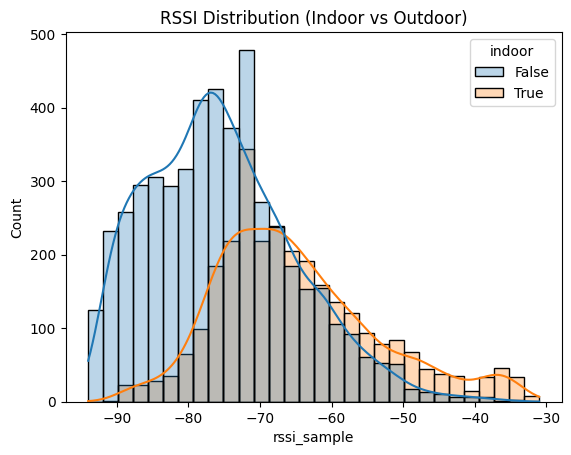

In [20]:
sns.histplot(data=wifi_df, x="rssi_sample", hue="indoor", bins=30, kde=True, alpha=0.3)
plt.title("RSSI Distribution (Indoor vs Outdoor)")
plt.show()

# 4. Time of day

Main idea: we know that we should model location and indoor/outdoor, but should we model time? We check by doing simple KNN for location and indoor/outdoor, then seeing if the residuals have any relation to time of day.

Potential problem: because of sampling design, it is possible location and time are correlated.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, Normalizer

In [22]:
wifi_df.head(5)

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1


In [23]:
numeric_to_scale = ["latitude", "longitude"]   # columns that need normalization

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_to_scale),
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid = {
    "model__n_neighbors": np.arange(10, 41),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan vs Euclidean
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",  # or "r2"
    n_jobs=-1,   # use all CPU cores
    verbose=0
)

In [24]:
var = 'rssi_set' # 'noise'

# df_knn = wifi_df[wifi_df[var].notna()].copy()
df_knn = agg_wifi_df[agg_wifi_df[var].notna()].copy()
# aggregate duplicate X values
# note: this may no longer be necessary after aggregating in preprocessing
# df_knn = df_knn.groupby(["latitude", "longitude", "indoor"], as_index=False)[var].mean()
grid.fit(df_knn[["latitude", "longitude", "indoor"]], df_knn[var])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': array([10, 11..., 38, 39, 40]), 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [25]:
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'model__n_neighbors': np.int64(10), 'model__p': 1, 'model__weights': 'distance'}
Best score: -57.55392354336383


In [26]:
wifi_df['time_pdt']

0       17:11:02.508330
1       17:11:03.719977
2       17:11:04.951550
3       17:11:07.470753
4       17:11:08.676819
             ...       
8716    18:15:32.228697
8717    18:15:32.927390
8718    18:15:35.567523
8719    18:15:36.235824
8720    18:15:36.945285
Name: time_pdt, Length: 8095, dtype: object

In [27]:
residuals = wifi_df[var] - grid.best_estimator_.predict(
    wifi_df[["latitude", "longitude", "indoor"]])
time_sec = wifi_df["time_pdt"].apply(lambda t: int(
    (hms := t.split(':'))[0])*3600 + int(hms[1])*60 + float(hms[2]))

We now visualize residuals vs. time.

In [28]:
mask = residuals.notna()

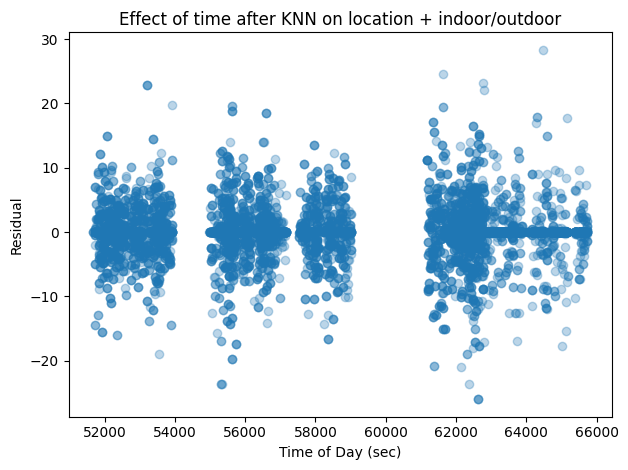

In [29]:
plt.scatter(time_sec[mask], residuals[mask], alpha=0.3)
plt.xlabel('Time of Day (sec)')
plt.ylabel('Residual')
plt.title('Effect of time after KNN on location + indoor/outdoor')
plt.tight_layout()

There doesn't seem to be any meaningful relationship. We will check with a linear regression.

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()
lr.fit(time_sec[mask].values.reshape(-1,1), residuals[mask])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
print(f"Fitted Intercept: {lr.intercept_}")
print(f"Fitted Slope: {lr.coef_[0]}")

Fitted Intercept: 0.6949302693217472
Fitted Slope: -1.1516572647077872e-05


# 5. Noise distribution

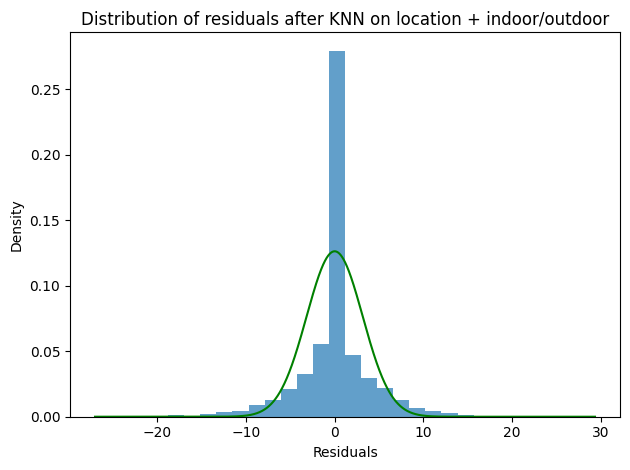

In [33]:
plt.hist(residuals[mask], bins=30, density=True, alpha=0.7)

norm_approx = sp.stats.norm(loc=np.median(residuals[mask]), scale=residuals[mask].std()-1)
lap_approx = sp.stats.laplace(loc=np.median(residuals[mask]), scale=residuals[mask].std()-1)
density_grid = np.arange(residuals[mask].min()-1, residuals[mask].max()+1, 1e-3)
plt.plot(density_grid, norm_approx.pdf(density_grid), c='green')
# plt.plot(density_grid, lap_approx.pdf(density_grid), c='red')

plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Distribution of residuals after KNN on location + indoor/outdoor')
plt.tight_layout()

# 6. Model Ideas

<div style="display:none">
$
\newcommand{\rssi}{\texttt{RSSI}}
\newcommand{\GP}{\mathcal{GP}}
\newcommand{\K}{\mathcal{K}}
\newcommand{\R}{\mathbb{R}}
\newcommand{\N}{\mathcal{N}}
$
</div>

## Setup

Define the variables of interest.
$$r = \rssi, \quad x = \texttt{longitude}, \quad y = \texttt{latitude}, \quad z = \texttt{indoor}$$

Assume that the signal field is described by a latent function $f$.
$$r_i = f(x_i, y_i, z_i) + \epsilon_i$$
where $\epsilon_i \sim \N(0, \sigma^2_i)$. How should we estimate the noise variance? Do we want to also model variance as a function of $x_i, y_i, z_i$?

<br><br>

## Model

We put a Gaussian process (GP) prior on $f$.
$$f \sim \GP(m, \K)$$
where $m: \R^3 \to \R$ mean function, $\K: \R^3 \times \R^3 \to \R$ covariance kernel. How to set $m$ and $\K$? We see that changes in $z$ lead to much sharper changes in $r$ compared to changes in $x$ and $y$. Can we capture this in our kernel?

<br>

Then, we have the full model below.
$$f \sim \GP(m, \K)$$
$$\vec{r} \mid f \sim \N(f(\vec{x}, \vec{y}, \vec{z}), \Sigma_0)$$
$$\Sigma_0 = \text{noise covariance matrix } \textrm{diag}(\sigma^2_i)$$
Note that under independent Gaussian noise with known/fixed variance, the posterior for this model is available in closed form. If we have unknown variance but homoskedasticity, a simple MCMC solution is available.

<br><br>

## More Advanced Directions

- Our measurements for $x_i$ and $y_i$ are noisy; how can we account for this in our model?
- A refined approach is to account for the WiFi access points on campus, for which we also have data. A reasonable assumption is that there is an access point in each building, though we could treat their locations as unknown parameters as well. Then, there are multiple ways to incoporate this into our model.

  The following are possible ammendments to the model.

  Global GP:
  - Let $d_i$ be the distance of point $(x_i, y_i)$ to its access point. Account for $d_i$ in $m$ and $\K$.
  - Account for access point $a_j$ in $m$ and $\K$. For new observations, set $\hat{f}(x_{new}, y_{new}, z_{new}) = \max_j f(x_{new}, y_{new}, z_{new}, a_j)$. Can also model access point as a random parameter, inducing a hierarchical structure.
  - Condition on additional constraints on the GP dynamics to reflect behavior (e.g. point repellers).

  <br>
  
  Local GPs: For each access point $a_j$, set a different GP prior $f_j \sim \GP(m, \K)$.
  - Define $\displaystyle f(x_i, y_i, z_i) = \sum_j \mathbb{1}\{j = \arg\min_j d(i, j)\} f_j(x_i, y_i, z_i)$, or $\displaystyle f(x_i, y_i, z_i) = \max_j f_j(x_i, y_i, z_i)$

 
    Hard assignments are problematic due to discontinuities on boundaries. Also, location and inferred strength don't necessarily directly correspond with access point due to potential noise and the tendency of devices to "stick" with suboptimal access points until connection becomes too bad.
  
  - Define $\displaystyle f(x_i, y_i, z_i) = \sum_j w_j(x_i, y_i) f_j(x_i, y_i, z_i)$

 
    where $w_j$ is a weight function for access point $j$ based on distance. A mixture reflects the "stickiness."

# 7. Access Points?

In [34]:
wifi_df.head()

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1


In [35]:
wifi_df['ap_code'] = wifi_df['ap'].astype('category').cat.codes

In [36]:
wifi_df['rssi_ap'] = wifi_df.groupby("ap_code")['rssi_sample'].transform("mean")

In [37]:
wifi_df.head()


,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,...,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index,ap_code,rssi_ap
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0,203,-67.809524
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1,203,-67.809524
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2,203,-67.809524
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0,203,-67.809524
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1,203,-67.809524


<Axes: >

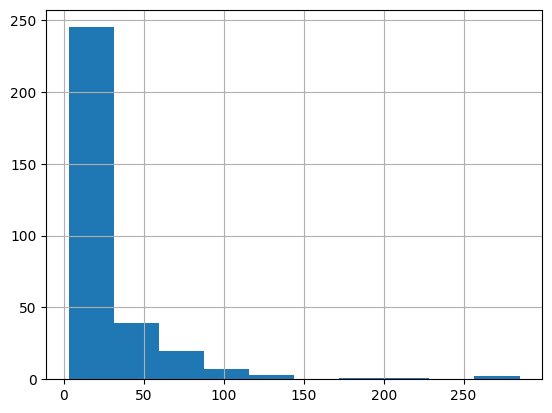

In [38]:
wifi_df['ap_code'].value_counts().hist()

In [39]:
wifi_df[
    wifi_df['ap_code'].isin(
        wifi_df['ap_code'].value_counts().iloc[:25].index
    )
]

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,...,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index,ap_code,rssi_ap
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0,203,-67.809524
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1,203,-67.809524
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2,203,-67.809524
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0,203,-67.809524
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,...,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1,203,-67.809524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8626,2026-05-11,18:13:32.118600,37.429524,-122.173009,False,90:77:ee:88:1e:8e,1,-74.333333,-74.0,True,...,-97.0,-97.0,3,True,2026-05-11 18:13:32.118600-07:00,2026-05-12 01:13:31+00:00,daef11b94871,1,130,-72.593496
8627,2026-05-11,18:13:32.821722,37.429546,-122.172972,False,90:77:ee:88:1e:8e,1,-74.333333,-76.0,True,...,-97.0,-97.0,3,True,2026-05-11 18:13:32.821722-07:00,2026-05-12 01:13:34+00:00,daef11b94871,2,130,-72.593496
8628,2026-05-11,18:13:35.437958,37.429546,-122.172972,False,90:77:ee:88:1e:8e,1,-78.000000,-77.0,True,...,-97.0,-97.0,3,True,2026-05-11 18:13:35.437958-07:00,2026-05-12 01:13:34+00:00,e9b8d98d5e3c,0,130,-72.593496
8629,2026-05-11,18:13:36.105987,37.429585,-122.172921,False,90:77:ee:88:1e:8e,1,-78.000000,-77.0,True,...,-97.0,-97.0,3,True,2026-05-11 18:13:36.105987-07:00,2026-05-12 01:13:38+00:00,e9b8d98d5e3c,1,130,-72.593496


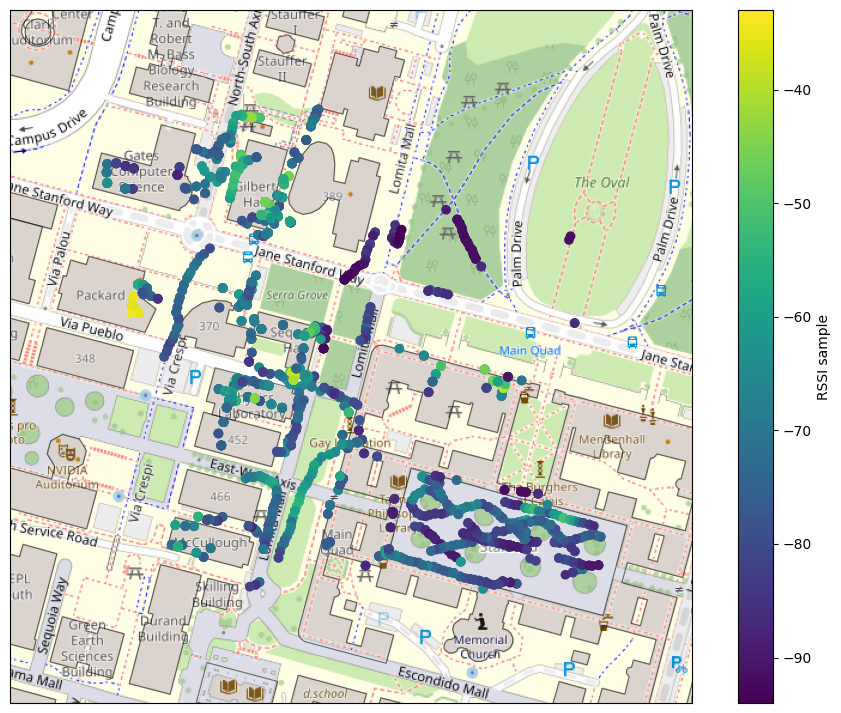

In [40]:
fig, ax, metadata = osm_context.generate_base_axis()
filt_df = wifi_df[lambda df: df['ap_code'].isin(
    df['ap_code'].value_counts().iloc[:25].index
)]
x_lon, x_lat = osm_context.to_world(
    lon=filt_df['longitude'], lat=filt_df['latitude'])
sc = ax.scatter(
    x_lon,
    x_lat,
    c=filt_df['rssi_sample']
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('RSSI sample')

In [ ]:
import importlib
importlib.reload(wp)

fig, ax, ap_regions = wp.plot_access_point_voronoi(
    wifi_df,
    context=osm_context,
    resolution=400,
    top_n=None, # 25,  # set to None to include every AP; 25 keeps the legend readable
    alpha=0.38,
)
display(ap_regions.head(25))
plt.show()